In [209]:
# Environment Setup
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("satyakidas07/retail-sales-dataset")
import os
import glob
# The 'path' variable from the previous cell contains the directory where the dataset was downloaded.
# It is '/root/.cache/kagglehub/datasets/satyakidas07/retail-sales-dataset/versions/1'
# We need to find the actual CSV file within this directory.

csv_files = glob.glob(os.path.join(path, '*.csv'))

if csv_files:
    data_file_path = csv_files[0]
    df = pd.read_csv(data_file_path)
    print(f"Successfully loaded data from: {data_file_path}")
else:
    raise FileNotFoundError(f"No CSV files found in the dataset directory: {path}")

Using Colab cache for faster access to the 'retail-sales-dataset' dataset.
Successfully loaded data from: /kaggle/input/retail-sales-dataset/retail_sales_dataset.csv


In [210]:
# Get information of the data
df

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4305,ORD-00056,2020-01-21,CUST85136,Sanjay Sharma,45.0,F,West,Pune,Sports,Football,...,1871.46,0.22,6895.34,1811.03,62.59,EMI,NaN,True,Returned,9.0
4306,ORD-03458,2024-02-08,CUST09746,Karan Pillai,25.0,m,South,Chennai,Clothing,Kurta,...,3147.97,0.13,22125.94,10153.44,38.76,EMI,2.0,False,Cancelled,2.0
4307,ORD-01769,2022-02-22,CUST64190,Karan Reddy,39.0,Male,East,Guwahati,Beauty,Face Cream,...,422.45,0.02,2726.49,759.36,39.41,Credit Card,NaN,False,Delivered,5.0
4308,ORD-01738,2022-02-11,CUST50460,Amit Mehta,40.0,Female,East,Bhubaneswar,Books,Biography,...,1456.57,0.27,4835.66,2312.44,71.90,Cash on Delivery,1.0,False,Cancelled,4.0


In [211]:
# Get the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   object 
 1   order_date             4280 non-null   object 
 2   customer_id            4280 non-null   object 
 3   customer_name          4280 non-null   object 
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   object 
 6   region                 4280 non-null   object 
 7   city                   4280 non-null   object 
 8   product_category       4280 non-null   object 
 9   product_name           4280 non-null   object 
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  ship

In [212]:
# Convert categorical type date column into datatime type
df['order_date'] = pd.to_datetime(df['order_date'],format='mixed')

In [213]:
# Performing descriptive statistics
df.describe().round()

,order_date,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4280,4150.0,4170.0,4280.0,4143.0,4280.0,4280.0,4280.0,3932.0,4180.0
mean,2022-07-06 09:49:47.663551488,35.0,7.0,10621.0,0.0,62359.0,11687.0,63.0,3.0,6.0
min,2020-01-01 00:00:00,-7.0,-1.0,50.0,0.0,39.0,2.0,-4.0,1.0,-1.0
25%,2021-04-20 00:00:00,26.0,3.0,672.0,0.0,2462.0,702.0,51.0,2.0,3.0
50%,2022-07-14 12:00:00,34.0,5.0,2228.0,0.0,9548.0,3128.0,63.0,3.0,6.0
75%,2023-09-26 06:00:00,42.0,8.0,12717.0,0.0,50070.0,10404.0,76.0,4.0,8.0
max,2024-12-30 00:00:00,999.0,999.0,79958.0,0.0,17360314.0,2445648.0,133.0,5.0,100.0
std,NaN,36.0,44.0,17324.0,0.0,316700.0,52875.0,18.0,1.0,4.0


In [214]:
# Count of missing values
df.isnull().sum()

,0
order_id,30
order_date,30
customer_id,30
customer_name,30
age,160
gender,30
region,30
city,30
product_category,30
product_name,30


In [215]:
df.shape

(4310, 21)

In [216]:
# Percentage of the missing datavalues
(df.isnull().sum()/len(df)*100)

,0
order_id,0.696056
order_date,0.696056
customer_id,0.696056
customer_name,0.696056
age,3.712297
gender,0.696056
region,0.696056
city,0.696056
product_category,0.696056
product_name,0.696056


In [217]:
df[df.duplicated()].shape

(109, 21)

In [218]:
df[df['customer_id'] == 'CUST85913'].T

,1627,2157,2248
order_id,ORD-03963,ORD-03963,ORD-00839
order_date,2024-09-05 00:00:00,2024-09-05 00:00:00,2021-01-19 00:00:00
customer_id,CUST85913,CUST85913,CUST85913
customer_name,Sunita Iyer,Sunita Iyer,Pooja Pillai
age,NaN,NaN,31.0
gender,Male,Male,male
region,Central,Central,South
city,Raipur,Raipur,Chennai
product_category,Sports,Sports,Furniture
product_name,Tennis Racket,Tennis Racket,Bookshelf


In [219]:
for col in df.columns:
  if df[col].nunique()<20:
    print(col)
    print(df[col].value_counts())
    print('-'*50)

gender
gender
Other     1442
Male      1207
Female    1191
male        68
MALE        62
f           57
m           55
F           54
M           50
FEMALE      49
female      45
Name: count, dtype: int64
--------------------------------------------------
region
region
South      885
West       880
North      872
East       846
Central    797
Name: count, dtype: int64
--------------------------------------------------
product_category
product_category
Clothing       645
Groceries      627
Sports         625
Electronics    615
Beauty         612
Furniture      583
Books          573
Name: count, dtype: int64
--------------------------------------------------
quantity
quantity
 9.0      438
 2.0      437
 8.0      436
 4.0      428
 3.0      423
 10.0     417
 1.0      416
 7.0      405
 5.0      382
 6.0      362
 0.0       12
 999.0      8
-1.0        6
Name: count, dtype: int64
--------------------------------------------------
payment_method
payment_method
UPI                 761
Cre

## Handling Missing data

In [220]:
df.dropna(subset=['customer_id'], inplace = True)

In [221]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
age,130
gender,0
region,0
city,0
product_category,0
product_name,0


In [253]:
import re
def extract_age(age):
  age_num = re.findall('[0-9]+', str(age))
  if len(age_num)>0:
    return age_num[0]
  else:
    return age
df['age'] = df['age'].apply(lambda x: extract_age(x))

In [271]:
df_age = df[df['age'] != 'nan']['age']

In [272]:
age_median = int(df_age.dropna().astype('int64').median())

In [276]:
df.replace('nan', age_median, inplace= True)

In [278]:
df['age'].fillna({'nan': age_median}, inplace = True)

In [279]:
df['age'].unique()

array(['39', '28', '41', '29', '9', '31', '43', '44', '17', '51', '14',
       '15', '53', '30', '26', '21', '35', '22', '20', '65', '27', '52',
       '42', '40', '6', '49', '999', '34', '38', '57', '36', '48', '37',
       34, '32', '33', '45', '23', '16', '10', '25', '24', '11', '12',
       '50', '54', '46', '56', '47', '19', '18', '58', '5', '66', '8',
       '61', '55', '2', '60', '63', '13', '59', '0', '1', '7', '150',
       '62', '69', '4', '68', '3', '71', '64', '67', '72'], dtype=object)

In [224]:
df['quantity']  = df['quantity'].fillna(df['quantity'].median())
df['discount_pct']  = df['discount_pct'].fillna(df['discount_pct'].mean())
df['customer_satisfaction']  = df['customer_satisfaction'].fillna(df['customer_satisfaction'].mode()[0])
df['days_to_ship']  = df['days_to_ship'].fillna(df['days_to_ship'].median())

In [225]:
def extract_quantity(quantity):
  quantity_num = re.findall('[0-9]+', str(quantity))
  if len(quantity_num)>0:
    return quantity_num[0]
  else:
    return quantity
df['quantity'] = df['quantity'].apply(lambda x: extract_age(x))

def for_shipping_cost(shipping_cost):
  shipping_cost_num = re.findall('[0-9]+', str(shipping_cost))
  if len(shipping_cost_num)>0:
    return shipping_cost_num[0]
  else:
    return shipping_cost
df['shipping_cost'] = df['shipping_cost'].apply(lambda x: extract_age(x))

In [226]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
age,130
gender,0
region,0
city,0
product_category,0
product_name,0


## Fixing inconsistent formatting

In [227]:
df['gender'].unique()

array(['Other', 'Male', 'Female', 'FEMALE', 'f', 'F', 'male', 'female',
       'MALE', 'M', 'm'], dtype=object)

In [228]:
df['gender']=df['gender'].str.lower().str.strip()
df['gender'].replace({'m':'male','f':'female'},inplace= True)

/tmp/ipykernel_1582/3898538674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace({'m':'male','f':'female'},inplace= True)


In [229]:
df['gender'].unique()

array(['other', 'male', 'female'], dtype=object)

In [230]:
df['product_name'].unique()

array(['Sugar', 'Sunscreen', 'Sofa', 'Bed Frame', 'Cooking Oil',
       'Self-Help Book', 'Saree', 'Kurta', 'Wardrobe', 'Dal (1kg)',
       'Lipstick', 'Cook Book', 'T-Shirt', 'Chair', 'Dress', 'Tablet',
       'Jacket', 'Headphones', 'Dumbbells', 'Comic Book', 'Football',
       'Laptop', 'Cricket Bat', 'Hair Oil', 'Bookshelf', 'Camera',
       'Jeans', 'Tennis Racket', 'Desk', 'Face Cream', 'Fiction Novel',
       'Cycle', 'Textbook', 'Smartwatch', 'Rice (5kg)', 'Tea', 'Flour',
       'Perfume', 'Yoga Mat', 'Smartphone', 'Biography', 'Shampoo'],
      dtype=object)

In [231]:
df['order_status']=df['order_status'].str.lower().str.strip()

In [232]:
# ERRORS IN DATASET
# days to ship m min is also negative here.
#Age mean = 999.0

## Handling duplicates

In [233]:
df[df.duplicated()].shape

(80, 21)

In [234]:
df.drop_duplicates(inplace = True)

In [235]:
df[df.duplicated()].shape

(0, 21)

In [236]:
df['customer_id'].value_counts()

,count
customer_id,
CUST00213,3
CUST18225,2
CUST12889,2
CUST94587,2
CUST63701,2
...,...
CUST52615,1
CUST92217,1
CUST89689,1


In [237]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='object')

In [280]:
df['age'] = df['age'].astype('int64')

In [286]:
df['quantity'] = df['quantity'].astype('int64')

In [288]:
df['shipping_cost']=df['shipping_cost'].astype('int64')

In [289]:
df.dtypes

,0
order_id,object
order_date,datetime64[ns]
customer_id,object
customer_name,object
age,int64
gender,object
region,object
city,object
product_category,object
product_name,object


# Handling Outliers

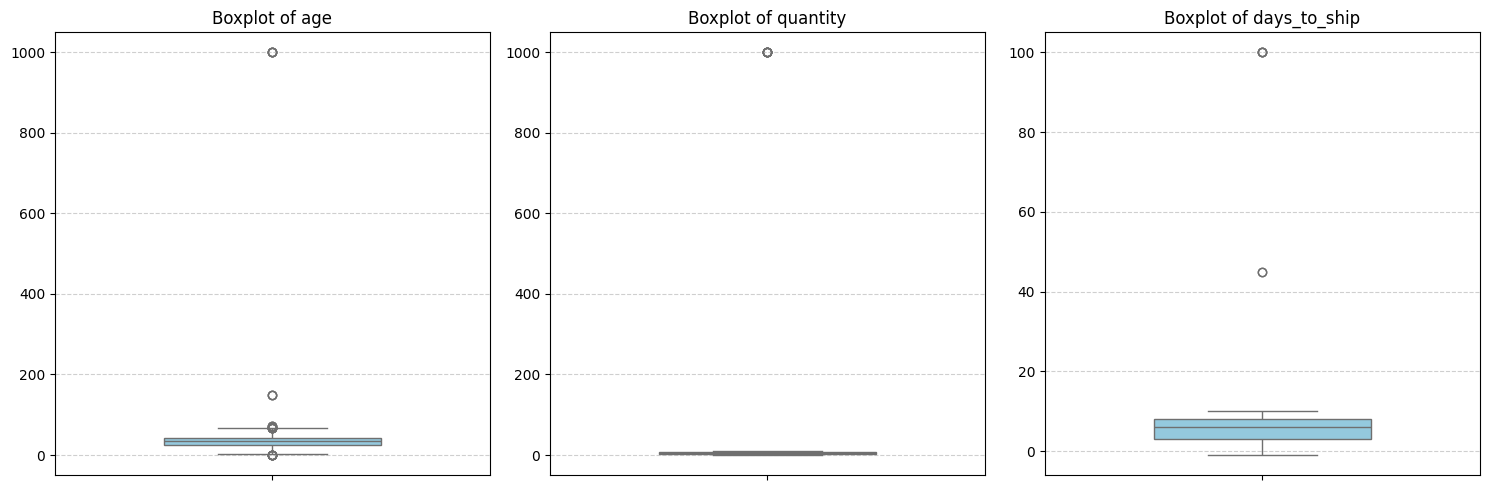

In [318]:
import seaborn as sns

cols = ['age', 'quantity', 'days_to_ship']
plt.figure(figsize=(15,5))
for i, cols in enumerate(cols):
  plt.subplot(1,3,i + 1)
  sns.boxplot(y=df[cols], color='skyblue', width = 0.5)
  plt.title(f'Boxplot of {cols}', fontsize=12)
  plt.ylabel('')
  plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [312]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_age = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print(f"Q1 for age: {Q1}")
print(f"Q3 for age: {Q3}")
print(f"IQR for age: {IQR}")
print(f"Lower bound for age: {lower_bound}")
print(f"Upper bound for age: {upper_bound}")
print(f"\nNumber of outliers in 'age': {len(outliers_age)}")
print("Outliers in 'age':")
display(outliers_age[['age']].sort_values(by='age'))

Q1 for age: 26.0
Q3 for age: 42.0
IQR for age: 16.0
Lower bound for age: 2.0
Upper bound for age: 66.0

Number of outliers in 'age': 26
Outliers in 'age':


,age
940,0
2570,0
2348,0
3525,0
3494,0
3999,1
2342,1
1143,1
3697,67
2742,67


In [319]:
from scipy import stats

In [326]:
import numpy as np
z_score = np.abs(stats.zscore(df[['age','quantity']]))

In [328]:
df_clean = df[~(z_score>3).any(axis = 1)]

In [329]:
df_clean.shape

(4185, 21)